<a href="https://colab.research.google.com/github/VarsanJ/Cities-in-Motion-2026/blob/main/CatBoostModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0:	learn: 2.1186814	total: 15.6ms	remaining: 23.4s
1:	learn: 2.0563471	total: 31.1ms	remaining: 23.3s
2:	learn: 1.9963372	total: 44.2ms	remaining: 22.1s
3:	learn: 1.9435084	total: 57.8ms	remaining: 21.6s
4:	learn: 1.8939238	total: 70.6ms	remaining: 21.1s
5:	learn: 1.8516228	total: 83.6ms	remaining: 20.8s
6:	learn: 1.8140499	total: 98.1ms	remaining: 20.9s
7:	learn: 1.7783965	total: 111ms	remaining: 20.8s
8:	learn: 1.7480196	total: 126ms	remaining: 20.8s
9:	learn: 1.7194706	total: 139ms	remaining: 20.7s
10:	learn: 1.6930002	total: 153ms	remaining: 20.7s
11:	learn: 1.6697361	total: 166ms	remaining: 20.6s
12:	learn: 1.6476490	total: 179ms	remaining: 20.5s
13:	learn: 1.6280857	total: 193ms	remaining: 20.5s
14:	learn: 1.6112387	total: 206ms	remaining: 20.4s
15:	learn: 1.5966723	total: 222ms	remaining: 20.6s
16:	learn: 1.5800846	total: 235ms	remaining: 20.5s
17:	learn: 1.5644111	total: 253ms	remaining: 20.8s
18:	learn: 1.5494620	total: 266ms	remaining: 20.7s
19:	learn: 1.5366716	total: 280ms	

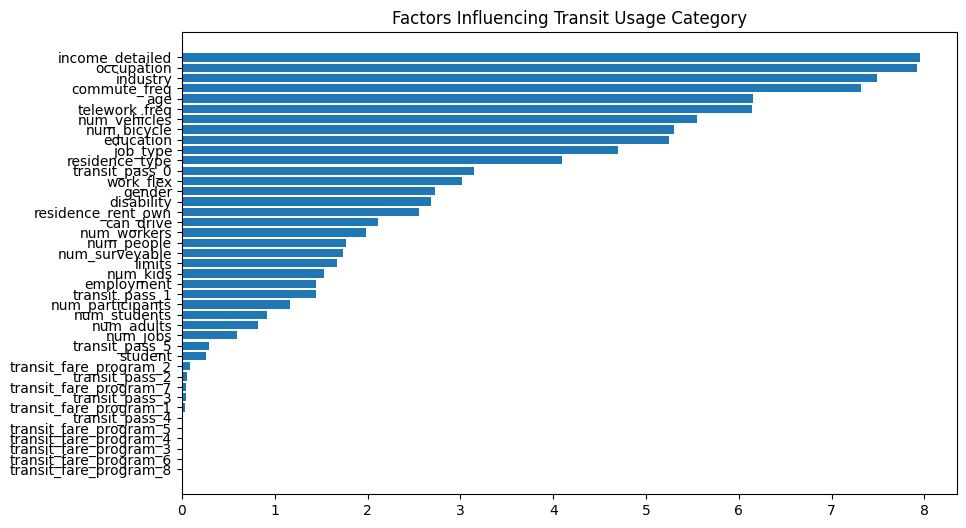


--- SHAP Summary Plot ---


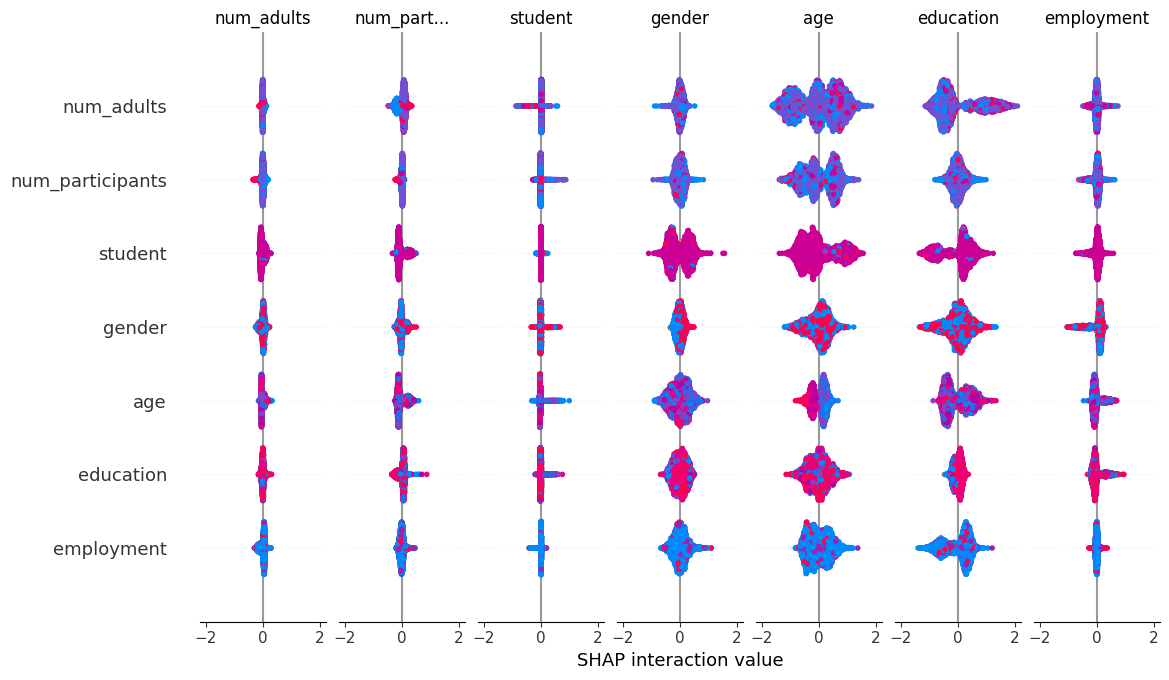


--- Partial Dependence for telework_freq ---


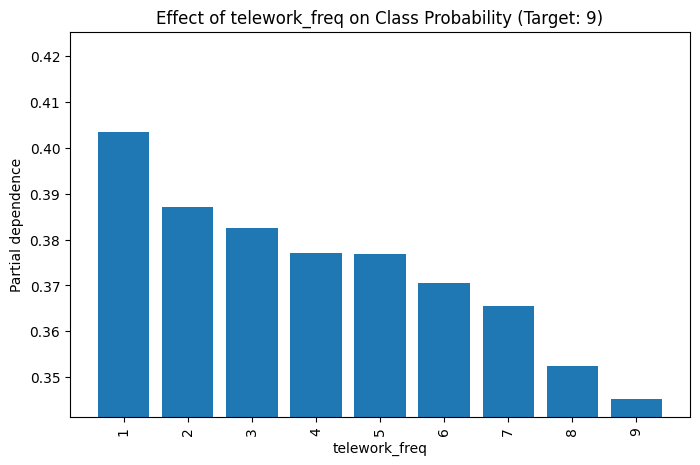

In [14]:
!pip install catboost shap -q

# Imports
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# File Import
fileImport = pd.read_csv("CMAP_NeededVariables.csv")

# Define The Dependent and Independent Variable so far
dependent_var = 'transit_freq'
independent_var = 'telework_freq'

# Handle Special Code Cases in a copy
fileImport_cleaned = fileImport.copy()
# Replace the 996 with 9 (Never)
fileImport_cleaned[dependent_var] = fileImport_cleaned[dependent_var].replace(996, 9)
# General custom codes for invalid responses
custom_codes = [995, 997, 998, 999, -1]
fileImport_cleaned = fileImport_cleaned.replace(custom_codes, np.nan)

fileImport_cleaned[independent_var] = fileImport_cleaned[independent_var].replace(
    [995, 996, 997, 998, 999, -1], np.nan
)

# Cleans variables
df = fileImport_cleaned.dropna(subset=[dependent_var]) # Can't train on NaN targets
X = df.drop(columns=[dependent_var, 'hh_id', 'home_tract_2020', 'work_tract_2020', 'person_weight']) # Drops hh_id as well, not to consider
y = df[dependent_var]

# Categorical Columns
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create Classification Model
model = CatBoostClassifier(
    iterations=1500, #
    learning_rate=0.05, #
    depth=6, #
    loss_function='MultiClass', # Use MultiClass for categorical frequency levels
    random_seed=42,
    nan_mode='Min', #
    verbose=True # Print outputs
)

# Model Training
model.fit(X, y, cat_features=cat_features)

# These graphs were asked by Masoud, some AI Generated below

# Feature Importance Plot
print("\n--- Feature Importance ---")
importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature Id'][::-1], importance['Importances'][::-1])
plt.title("Factors Influencing Transit Usage Category")
plt.show()

# SHAP Value Summary Plot
print("\n--- SHAP Summary Plot ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# Partial Dependence Plot
print(f"\n--- Partial Dependence for {independent_var} ---")

fig, ax = plt.subplots(figsize=(8, 5))

most_frequent_class = y.mode()[0]

PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=[independent_var],
    target=most_frequent_class,
    categorical_features=[independent_var],
    ax=ax
)
# Define graph properties
plt.title(f'Effect of {independent_var} on Class Probability (Target: {most_frequent_class})')
plt.xticks(range(1, 10))
plt.show()